<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Object_classification_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object classification**

## **Context**

In this tutorial we will conduct object classification using YOLOv8. Object classification is a fundamental task in computer vision that involves categorizing objects within an image into predefined classes. It goes beyond simply detecting the presence of objects by also identifying *what* those objects are.

YOLO (You Only Look Once) is a popular family of object detection models known for its speed and accuracy. YOLOv8 is the latest iteration, offering advancements in performance and ease of use. While primarily known for object detection (identifying bounding boxes and classes), the `yolov8m-cls.pt` model used in this notebook is specifically a classification model. This means it's designed to classify the entire input image into one of its trained categories, rather than detecting multiple objects and their locations within the image. In this context, it will classify the primary object or the overall theme of the image.

**Benefits of Object Classification with YOLOv8**

*   **Speed and Efficiency:** YOLOv8 is designed for real-time applications, making it highly efficient for classifying images quickly. This is crucial for scenarios requiring rapid processing.
*   **Accuracy:** Despite its speed, YOLOv8 maintains a high level of accuracy in classifying objects, thanks to its optimized architecture and training methodologies.
*   **Ease of Use:** The Ultralytics library, which provides YOLOv8, offers a user-friendly interface, simplifying model loading, prediction, and result visualization.
*   **Versatility:** While this notebook uses a classification-specific model, the YOLO family is versatile, with models capable of object detection, instance segmentation, and pose estimation, making it a powerful toolkit for various computer vision tasks.

**Limitations**

*   **Single Object Classification:** The `yolov8m-cls.pt` model used here is a classification model, meaning it predicts a single class for the entire image. It will not identify multiple objects or their locations within an image. For multi-object detection and localization, a different YOLO model (e.g., `yolov8m.pt`) would be required.
*   **Pre-trained Categories:** The model is trained on a specific dataset (like ImageNet), and its classification capabilities are limited to the categories it was trained on. It may not perform well on objects outside its training data.
*   **Contextual Ambiguity:** For complex scenes with multiple objects or obscured views, classifying the 'primary' object or overall theme can be challenging and sometimes ambiguous.

**Initial setup**

In [8]:
# Installing additional library
# !pip install ultralytics #Remove the ('#') to install

In [2]:
# Importing libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


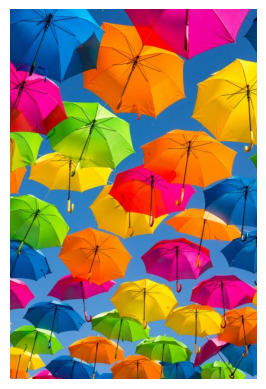

In [3]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/payung.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

**Preparing YOLO model**

In [4]:
# Preparing YOLOv8

# Downloading YOLOv8 starter files
model = YOLO('yolov8m-cls.pt')

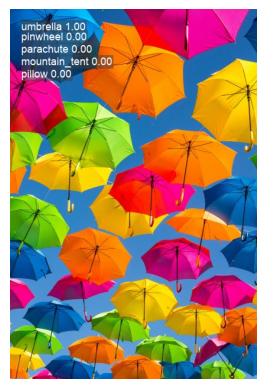

In [7]:
# Conduting object classification (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot classification result on the input image
img_detect = result.plot(line_width=15)

# Displaying the detected image
plt.axis('off')
plt.imshow(img_detect)
plt.show()

The detection shows that the image is classified as umbrella with score of 100%

Let's try another object

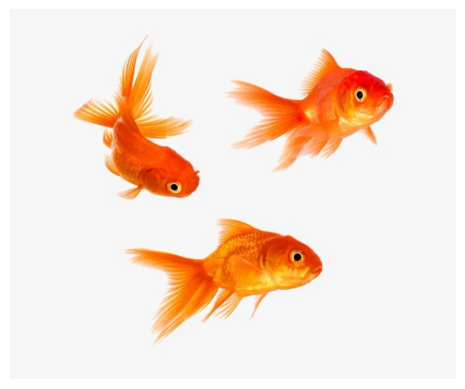

In [18]:
# Attaching the second input image

# Image link
url_fish = 'https://i.pinimg.com/736x/0a/86/5b/0a865bc483dec0d0423fa77184801f8e.jpg'
# Download and open the image
with urllib.request.urlopen(url_fish) as f:
    input_img_fish = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img_fish = np.array(input_img_fish)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_fish, cmap='gray')
plt.show()

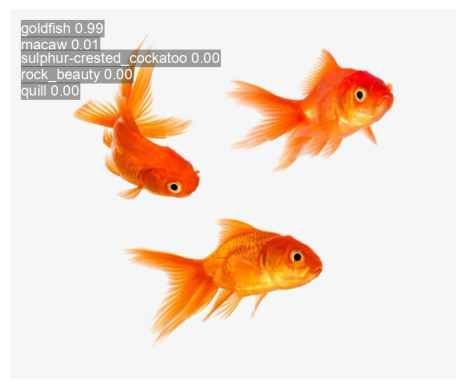

In [19]:
# Conduting object classification (YOLOv8) in input image
prediction = model.predict(input_img_fish, agnostic_nms=True)
result = prediction[0]

# plot classification result on the input image
img_detect_fish = result.plot(line_width=15)

# Displaying the detected image
plt.axis('off')
plt.imshow(img_detect_fish)
plt.show()

We get the identified object as 'goldfish' with 99% confidence

## **Conclusion**

This tutorial demonstrates how to perform object classification using YOLOv8's classification model (`yolov8m-cls.pt`). We have attached an image, loaded the pre-trained YOLOv8 classification model, and used it to predict the class of the input image. The model accurately identified the first object as an 'umbrella' with 100% confidence and the second object as a 'goldfish' with 99% confidence.

While this specific model is excellent for image classification, it's important to remember its limitations, such as only classifying the entire image and not detecting multiple objects within it. For more complex tasks like multi-object detection and localization, other YOLO models (e.g., `yolov8m.pt`) would be more appropriate.